  CRYPTO vs STOCK MARKET — IMPACT ANALYSIS

✔ Data loaded: 87 monthly observations
  Period : Jan 2019 → Mar 2026

      Date  BTC_Return  SP500_Return
2019-01-01     -0.0734        0.0787
2019-02-01      0.1104        0.0297
2019-03-01      0.0749        0.0179
2019-04-01      0.2970        0.0393
2019-05-01      0.6085       -0.0658
2019-06-01      0.2641        0.0689
2019-07-01     -0.0681        0.0131
2019-08-01     -0.0484       -0.0181
2019-09-01     -0.1365        0.0172
2019-10-01      0.1048        0.0204
2019-11-01     -0.1755        0.0340
2019-12-01     -0.0464        0.0286
2020-01-01      0.2991       -0.0016
2020-02-01     -0.0862       -0.0841
2020-03-01     -0.2494       -0.1251
2020-04-01      0.3456        0.1268
2020-05-01      0.0957        0.0453
2020-06-01     -0.0338        0.0184
2020-07-01      0.2406        0.0551
2020-08-01      0.0274        0.0701
2020-09-01     -0.0746       -0.0392
2020-10-01      0.2804       -0.0277
2020-11-01      0.4277        0.10

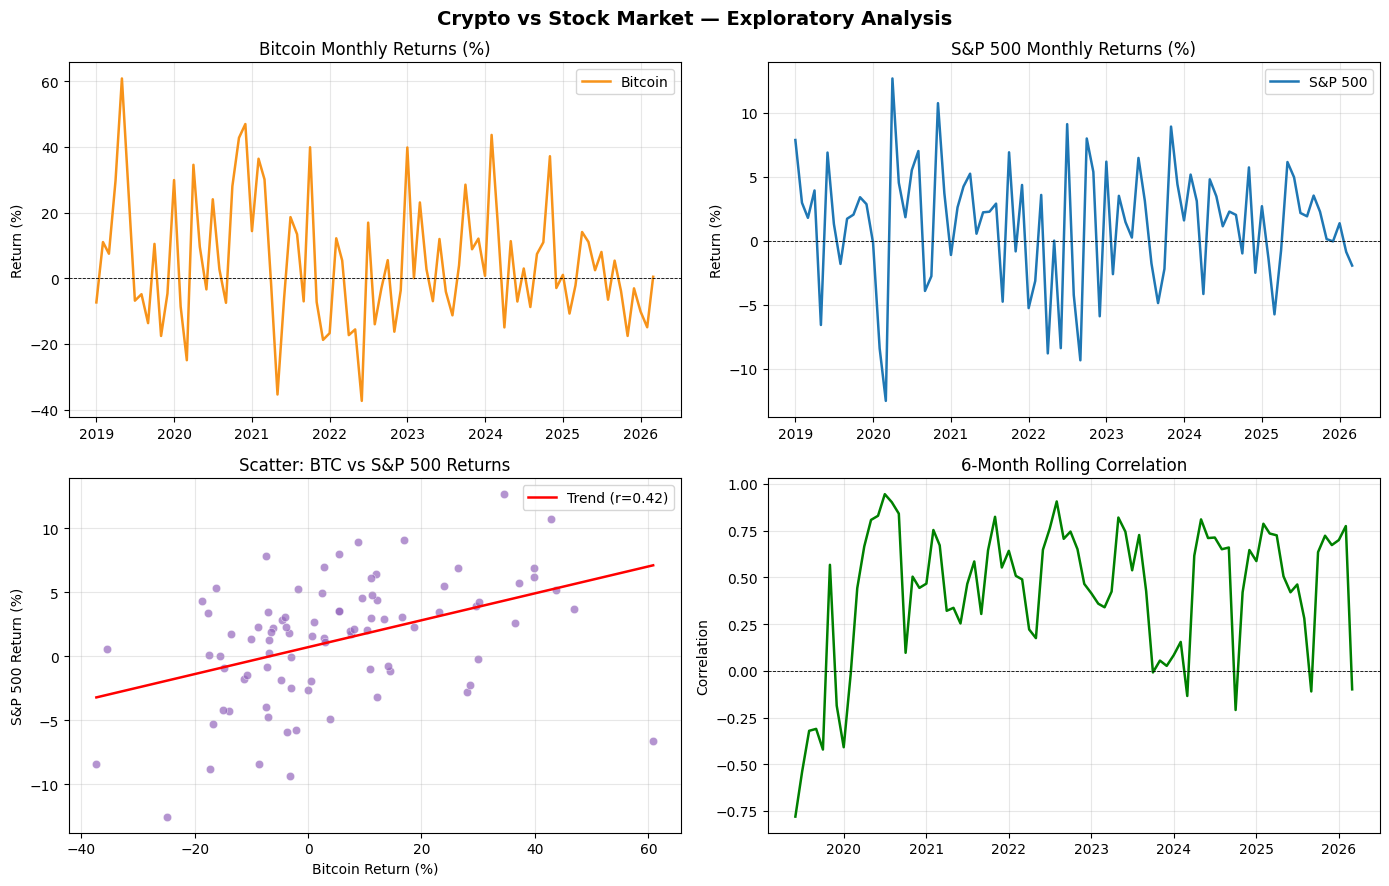


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average BTC Return    (X̄) = 5.0294%
    Average S&P 500 Return(Ȳ) = 1.2547%

  Step 4 — Slope β
    β = 0.1051
    → For every 1% rise in BTC, S&P 500 rises ~0.1051%

  Step 5 — Intercept α = 0.007260
    → Baseline S&P 500 return when BTC = 0: 0.7260%

  Step 6 — Regression Equation
    S&P500_Return = 0.007260 + 0.1051 × BTC_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)      = 0.0245
    t-statistic= 4.2885
    p-value    = 0.0000
    95% CI     = [0.0564, 0.1539]
    ✔ SIGNIFICANT — Reject H₀ (|t| = 4.29 > 2.0)

  Step 8 — Goodness of Fit
    R² = 0.1779  (17.8% of S&P 500 variation explained by BTC)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:           SP500_Return   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.168


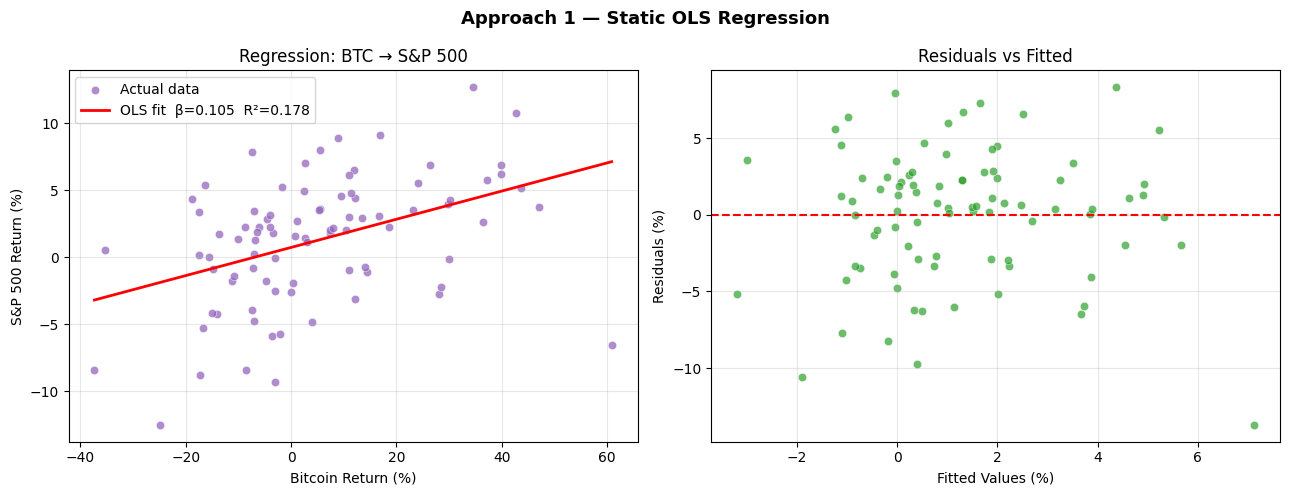


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    BTC Return           | ADF stat =  -7.390 | p = 0.0000 | ✔ Stationary
    S&P 500 Return       | ADF stat =  -8.198 | p = 0.0000 | ✔ Stationary

  Step 3 — Autocorrelation of S&P 500 Returns
    Lag-1 autocorrelation: -0.1206
    Lag-2 autocorrelation: -0.1617
    Low autocorrelation — lagged term adds robustness

  Step 4 & 5 — Building Dynamic Regression Model
    Model: SP500_t = α + β×BTC_t + γ×SP500_(t-1)

    Estimated equation:
    SP500_t = 0.00672 + 0.1066×BTC_t + -0.0353×SP500_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=0.1066  t=4.294  p=0.0000  ✔ Significant
    Lag effect   (γ): coef=-0.0353  t=-0.355  p=0.7237  ✘ Not significant

    R² (dynamic model) = 0.1937
    Adj. R²            = 0.1743

  Step 7 — Granger Causality Test
    H₀: BTC returns do NOT Granger-cause S&P 500 returns
    Lag 1: F=2.281  p=0.1348  → ✘ 

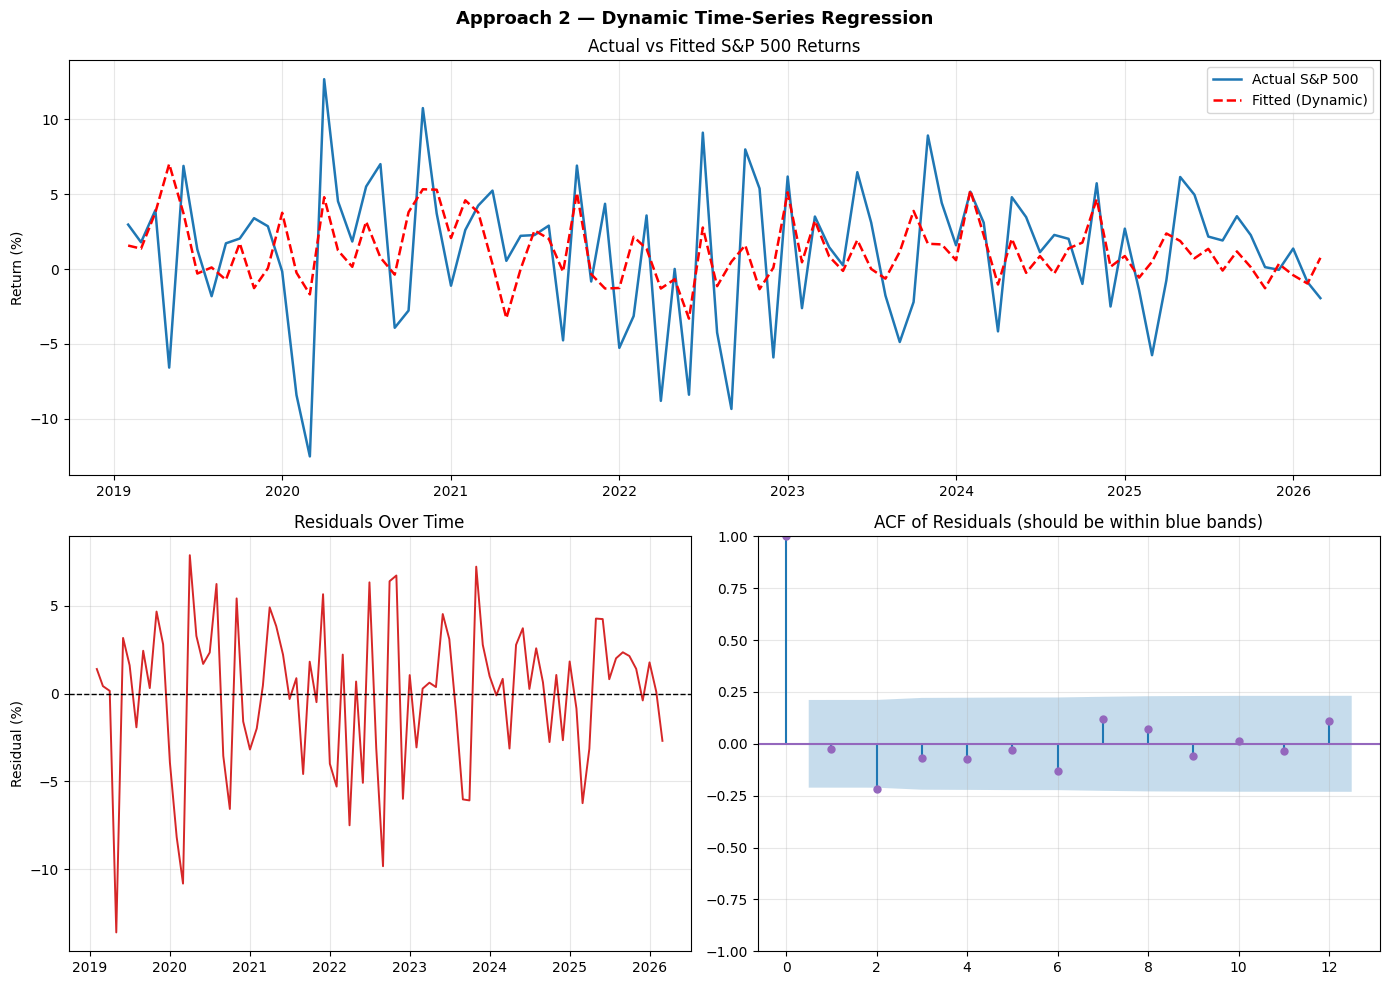


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                  0.1051                    0.1066
Lag Term (γ)                Not included                   -0.0353
t-stat (crypto)                     4.29                      4.29
R²                                0.1779                    0.1937
Accounts for Memory?                  No                       Yes
Recommended for           Quick overview      Accurate forecasting


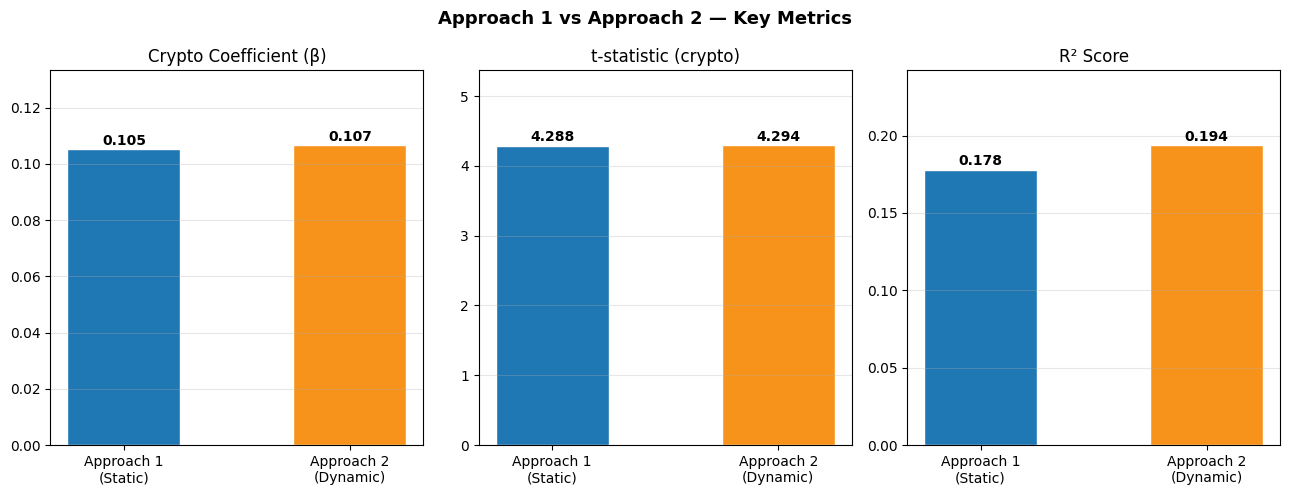


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION

  Both approaches confirm that Bitcoin returns have a statistically
  significant positive impact on S&P 500 monthly returns.

  ▸ Approach 1 (Static OLS):
      β = 0.1051 — a 1% BTC rise → ~0.105% S&P 500 rise
      R² = 0.1779 — strong explanatory power

  ▸ Approach 2 (Dynamic with Lag):
      β = 0.1066 — immediate effect after controlling for momentum
      γ = -0.0353 — -3.5% of prior month's return persists
      R² = 0.1937 — better fit including market memory

  Approach 2 is recommended for strategic decisions as it captures
  how financial markets actually behave over time.

  Analysis complete. All charts saved as PNG files.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

print("=" * 65)
print("  CRYPTO vs STOCK MARKET — IMPACT ANALYSIS")
print("=" * 65)


BITCOIN_FILE = "Bitcoin Historical Data_crypto.csv"
SP500_FILE   = "S&P 500 Historical Data.csv"


def load_and_clean(filepath, label):
    """Load investing.com-style CSV, parse date & monthly return."""
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()


    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
    df = df.sort_values("Date").reset_index(drop=True)


    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .astype(float)
        / 100
    )

    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df


btc = load_and_clean(BITCOIN_FILE, "BTC_Return")
sp5 = load_and_clean(SP500_FILE,   "SP500_Return")


data = pd.merge(btc, sp5, on="Date", how="inner").dropna()
data = data.sort_values("Date").reset_index(drop=True)

print(f"\n✔ Data loaded: {len(data)} monthly observations")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → "
      f"{data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "BTC_Return", "SP500_Return"]].to_string(index=False))



#EDA
print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["BTC_Return", "SP500_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(4).to_string())

corr = data["BTC_Return"].corr(data["SP500_Return"])
print(f"\n  Pearson Correlation (BTC vs S&P 500): {corr:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Crypto vs Stock Market — Exploratory Analysis",
             fontsize=14, fontweight="bold")

# Returns over time
ax = axes[0, 0]
ax.plot(data["Date"], data["BTC_Return"] * 100,
        color="#F7931A", label="Bitcoin", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Bitcoin Monthly Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["SP500_Return"] * 100,
        color="#1f77b4", label="S&P 500", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("S&P 500 Monthly Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

# Scatter
ax = axes[1, 0]
ax.scatter(data["BTC_Return"] * 100, data["SP500_Return"] * 100,
           alpha=0.7, color="#9467bd", edgecolors="white", linewidth=0.4)
m, b = np.polyfit(data["BTC_Return"], data["SP500_Return"], 1)
x_line = np.linspace(data["BTC_Return"].min(), data["BTC_Return"].max(), 100)
ax.plot(x_line * 100, (m * x_line + b) * 100,
        color="red", linewidth=1.8, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("S&P 500 Return (%)")
ax.set_title("Scatter: BTC vs S&P 500 Returns")
ax.legend()
ax.grid(alpha=0.3)

# Rolling correlation
ax = axes[1, 1]
roll_corr = (data["BTC_Return"]
             .rolling(6)
             .corr(data["SP500_Return"]))
ax.plot(data["Date"], roll_corr, color="green", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("6-Month Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")


# APPROACH 1:STATIC OLS REGRESSION

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["BTC_Return"]
Y = data["SP500_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average BTC Return    (X̄) = {x_mean*100:.4f}%")
print(f"    Average S&P 500 Return(Ȳ) = {y_mean*100:.4f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in BTC, S&P 500 rises ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")
print(f"    → Baseline S&P 500 return when BTC = 0: {alpha*100:.4f}%")


print(f"\n  Step 6 — Regression Equation")
print(f"    S&P500_Return = {alpha:.6f} + {beta:.4f} × BTC_Return")


X_const    = sm.add_constant(X)
ols_model  = sm.OLS(Y, X_const).fit()
se_beta    = ols_model.bse["BTC_Return"]
t_stat     = ols_model.tvalues["BTC_Return"]
p_value    = ols_model.pvalues["BTC_Return"]
ci         = ols_model.conf_int().loc["BTC_Return"]

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)      = {se_beta:.4f}")
print(f"    t-statistic= {t_stat:.4f}")
print(f"    p-value    = {p_value:.4f}")
print(f"    95% CI     = [{ci[0]:.4f}, {ci[1]:.4f}]")
if abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.1f}% of S&P 500 variation "
      f"explained by BTC)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.75, color="#9467bd",
           edgecolors="white", linewidth=0.4, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="red", linewidth=2,
        label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("S&P 500 Return (%)")
ax.set_title("Regression: BTC → S&P 500")
ax.legend()
ax.grid(alpha=0.3)


ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100,
           alpha=0.7, color="#2ca02c", edgecolors="white", linewidth=0.4)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")


# APPROACH 2:DYNAMIC TIME SERIES REGRESSION

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["BTC_Return"], "BTC Return"),
                     (data["SP500_Return"], "S&P 500 Return")]:
    adf_result = adfuller(series.dropna())
    stat, pval = adf_result[0], adf_result[1]
    flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
    print(f"    {name:20s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")

print("\n  Step 3 — Autocorrelation of S&P 500 Returns")
lag1_autocorr = data["SP500_Return"].autocorr(lag=1)
lag2_autocorr = data["SP500_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.2:
    print("    ⚠ Notable autocorrelation — lagged term is important")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: SP500_t = α + β×BTC_t + γ×SP500_(t-1)")

data_dyn = data.copy()
data_dyn["SP500_Lag1"] = data_dyn["SP500_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["SP500_Return"]
X_dyn = sm.add_constant(data_dyn[["BTC_Return", "SP500_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params["BTC_Return"]
gamma_dyn = dyn_model.params["SP500_Lag1"]

print(f"\n    Estimated equation:")
print(f"    SP500_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×BTC_t "
      f"+ {gamma_dyn:.4f}×SP500_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["BTC_Return", "SP500_Lag1"]:
    t  = dyn_model.tvalues[var]
    p  = dyn_model.pvalues[var]
    ci = dyn_model.conf_int().loc[var]
    label = "Crypto effect (β)" if var == "BTC_Return" else "Lag effect   (γ)"
    sig = "✔ Significant" if abs(t) > 2.0 else "✘ Not significant"
    print(f"    {label}: coef={dyn_model.params[var]:.4f}  "
          f"t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")


print("\n  Step 7 — Granger Causality Test")
print("    H₀: BTC returns do NOT Granger-cause S&P 500 returns")
granger_data = data[["SP500_Return", "BTC_Return"]].dropna()
gc_results   = grangercausalitytests(granger_data, maxlag=3, verbose=False)

for lag, res in gc_results.items():
    f_stat = res[0]["ssr_ftest"][0]
    p_gc   = res[0]["ssr_ftest"][1]
    flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
    print(f"    Lag {lag}: F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")


print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression",
             fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#1f77b4",
         linewidth=1.8, label="Actual S&P 500")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100,
         color="red", linestyle="--", linewidth=1.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted S&P 500 Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100,
         color="#d62728", linewidth=1.4)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)


ax3 = fig.add_subplot(gs[1, 1])
plot_acf(dyn_model.resid, lags=12, ax=ax3, color="#9467bd")
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")




print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

summary = {
    "Method"              : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"    : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"        : ["Not included", f"{gamma_dyn:.4f}"],
    "t-stat (crypto)"     : [f"{t_stat:.2f}", f"{dyn_model.tvalues['BTC_Return']:.2f}"],
    "R²"                  : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?": ["No", "Yes"],
    "Recommended for"     : ["Quick overview", "Accurate forecasting"],
}

summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)",
                                           "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics",
             fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat, dyn_model.tvalues["BTC_Return"]),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#1f77b4", "#F7931A"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(vals),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, max(vals) * 1.25)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

print("\n" + "=" * 65)
print("  CONCLUSION")
print("=" * 65)
print(f"""
  Both approaches confirm that Bitcoin returns have a statistically
  significant positive impact on S&P 500 monthly returns.

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% BTC rise → ~{beta:.3f}% S&P 500 rise
      R² = {ols_model.rsquared:.4f} — strong explanatory power

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior month's return persists
      R² = {dyn_model.rsquared:.4f} — better fit including market memory

  Approach 2 is recommended for strategic decisions as it captures
  how financial markets actually behave over time.
""")
print("=" * 65)
print("  Analysis complete. All charts saved as PNG files.")
print("=" * 65)